<a href="https://colab.research.google.com/github/haramkim1003-uxu/-1/blob/main/250510_%EB%8F%85%EB%A6%BD%ED%91%9C%EB%B3%B8_t_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
myfile = files.upload()

Saving iris.csv to iris (4).csv


In [ ]:
import pandas as pd
import io

In [ ]:
df = pd.read_csv(io.BytesIO(myfile['iris (4).csv']))

In [ ]:
df

,species,sepal
0,1,5.1
1,1,4.9
2,1,4.7
3,1,4.6
4,1,5.0
...,...,...
95,2,5.7
96,2,5.7
97,2,6.2
98,2,5.1


In [ ]:
from numpy import array

In [ ]:
x1 = array(df.sepal[0:50])

In [ ]:
x1

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. ])

In [ ]:
x2 = array(df.sepal[50:100])

In [ ]:
x2

NameError: name 'x2' is not defined

In [ ]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x7a76b2505a10>,
 'caps': [<matplotlib.lines.Line2D at 0x7a76b2506e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a76b24f7a90>,
 'medians': [<matplotlib.lines.Line2D at 0x7a76b2510590>,
 'fliers': [<matplotlib.lines.Line2D at 0x7a76b2510e50>,
 'means': []}

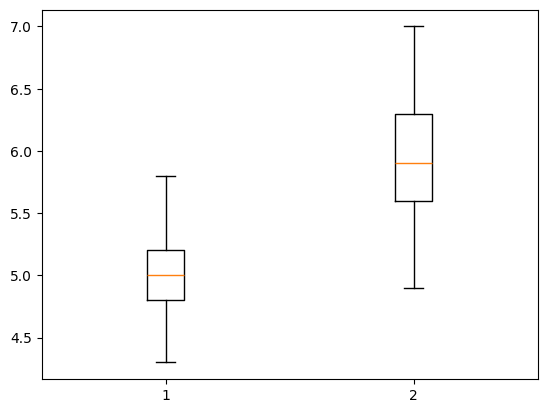

In [ ]:
plt.boxplot([x1, x2])

Text(0.5, 1.0, 'Iris Box Plot')

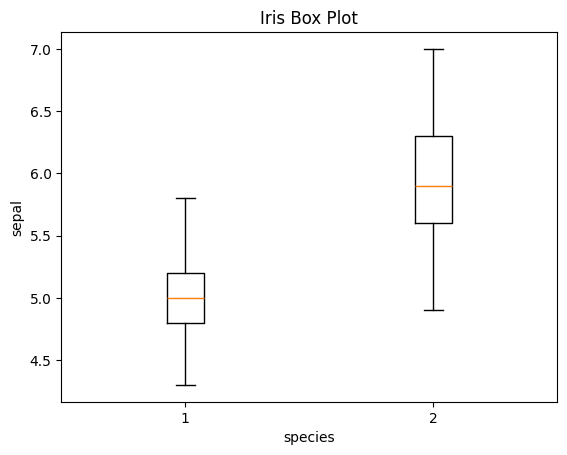

In [ ]:
plt.boxplot([x1,x2])
plt.xlabel('species')
plt.ylabel('sepal')
plt.title('Iris Box Plot')

In [ ]:
import numpy as np

In [ ]:
np.mean(x1)

np.float64(5.006)

In [ ]:
np.mean(x2)

np.float64(5.936)

4.정규성을 충족하는지 살펴보기

In [ ]:
#정규성 검사: shapiro-wilks test
#p값(p-value)dl 0.05보다 크면 정규성을 만족한다
from scipy.stats import shapiro

In [ ]:
shapiro(x1)

ShapiroResult(statistic=np.float64(0.977698549796646), pvalue=np.float64(0.4595131499174534))

In [ ]:
shapiro(x2)

ShapiroResult(statistic=np.float64(0.9778356785897521), pvalue=np.float64(0.4647370359250263))

5. 등분산성을 충족하는지 살펴보기

In [ ]:
#등분산성검사: Levene's test
#p값(p-value)이 0.05보다 크면 등분산성을 만족한다.
from scipy.stats import levene

In [ ]:
levene(x1,x2)

LeveneResult(statistic=np.float64(8.172720533728683), pvalue=np.float64(0.005195521631017526))

6. 적절한 t-test 기법을 적용하기
*정규성 만족/등분산성 만족: STUDENT's t-test
*정규성 만족/등분산성 만족x: Welch's t-test
*정규성 만족x: Mann-Whitney U-tes

In [ ]:
#Welch's t-test
#p값(p-value)이 0.05보다 "작으면", 두 집단은 유의미한 차이가 있다.
from scipy.stats import ttest_ind

In [ ]:
ttest_ind(x1,x2, equal_var = False)

TtestResult(statistic=np.float64(-10.52098626754911), pvalue=np.float64(3.746742613983842e-17), df=np.float64(86.53800179765497))

In [ ]:
#STUDENT's t-test
from scipy.stats import ttest_ind

In [ ]:
ttest_ind(x1,x2)

TtestResult(statistic=np.float64(-10.52098626754911), pvalue=np.float64(8.985235037487079e-18), df=np.float64(98.0))

In [ ]:
#Mann-Whitney U-test
from scipy.stats import mannwhitneyu

In [ ]:
mannwhitneyu(x1,x2)

MannwhitneyuResult(statistic=np.float64(168.5), pvalue=np.float64(8.34582714594069e-14))